<a href="https://colab.research.google.com/github/student-Ashishjha/face_generator/blob/main/facegenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import os

print(os.listdir("dataset"))

['faces']


In [ ]:
print(len(os.listdir("dataset/faces")))

12080


In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torchvision import datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
dataset = datasets.ImageFolder(
    root="dataset",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

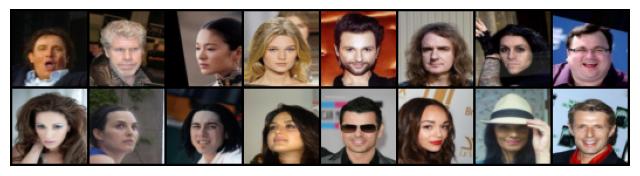

In [ ]:
real_batch = next(iter(loader))

plt.figure(figsize=(8,8))

plt.axis("off")

plt.imshow(
    torchvision.utils.make_grid(
        real_batch[0][:16],
        normalize=True
    ).permute(1,2,0)
)

plt.show()

In [ ]:
class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()

        self.main = nn.Sequential(

            # Input = 100 x 1 x 1

            nn.ConvTranspose2d(
                100, 512, 4, 1, 0, bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 512 x 4 x 4

            nn.ConvTranspose2d(
                512, 256, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 8 x 8

            nn.ConvTranspose2d(
                256, 128, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 16 x 16

            nn.ConvTranspose2d(
                128, 64, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 32 x 32

            nn.ConvTranspose2d(
                64, 3, 4, 2, 1, bias=False
            ),
            nn.Tanh()

            # Output = 3 x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

In [ ]:
G = Generator().to(device)

print(G)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [ ]:
class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(

            # Input = 3 x 64 x 64

            nn.Conv2d(
                3, 64, 4, 2, 1, bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32

            nn.Conv2d(
                64, 128, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 16 x 16

            nn.Conv2d(
                128, 256, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 x 8 x 8

            nn.Conv2d(
                256, 512, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 512 x 4 x 4

            nn.Conv2d(
                512, 1, 4, 1, 0, bias=False
            ),
            nn.Sigmoid()

            # Output = probability
        )

    def forward(self, input):
        return self.main(input)

In [ ]:
D = Discriminator().to(device)

print(D)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [ ]:
criterion = nn.BCELoss()

In [ ]:
optimizerD = torch.optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizerG = torch.optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [ ]:
fixed_noise = torch.randn(
    16,
    100,
    1,
    1,
    device=device
)

In [ ]:
num_epochs = 100

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    for i, data in enumerate(loader, 0):

        ############################
        # TRAIN DISCRIMINATOR
        ############################

        D.zero_grad()

        # REAL IMAGES

        real_images = data[0].to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(
            batch_size,
            device=device
        )

        output = D(real_images).view(-1)

        lossD_real = criterion(
            output,
            real_labels
        )

        lossD_real.backward()

        # FAKE IMAGES

        noise = torch.randn(
            batch_size,
            100,
            1,
            1,
            device=device
        )

        fake_images = G(noise)

        fake_labels = torch.zeros(
            batch_size,
            device=device
        )

        output = D(
            fake_images.detach()
        ).view(-1)

        lossD_fake = criterion(
            output,
            fake_labels
        )

        lossD_fake.backward()

        lossD = lossD_real + lossD_fake

        optimizerD.step()

        ############################
        # TRAIN GENERATOR
        ############################

        G.zero_grad()

        labels = torch.ones(
            batch_size,
            device=device
        )

        output = D(fake_images).view(-1)

        lossG = criterion(
            output,
            labels
        )

        lossG.backward()

        optimizerG.step()

    ############################
    # SAVE LOSSES
    ############################

    G_losses.append(lossG.item())
    D_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss D: {lossD.item():.4f} "
        f"Loss G: {lossG.item():.4f}"
    )

Epoch [1/100] Loss D: 1.0726 Loss G: 7.0221
Epoch [2/100] Loss D: 0.5050 Loss G: 8.1411
Epoch [3/100] Loss D: 0.0395 Loss G: 6.1331
Epoch [4/100] Loss D: 0.4045 Loss G: 1.4408
Epoch [5/100] Loss D: 0.1923 Loss G: 3.6977
Epoch [6/100] Loss D: 0.1285 Loss G: 4.6143
Epoch [7/100] Loss D: 0.1679 Loss G: 3.6197
Epoch [8/100] Loss D: 0.1060 Loss G: 5.9990
Epoch [9/100] Loss D: 0.1124 Loss G: 4.6169
Epoch [10/100] Loss D: 0.1772 Loss G: 3.0505
Epoch [11/100] Loss D: 1.1124 Loss G: 2.0337
Epoch [12/100] Loss D: 0.6959 Loss G: 1.4200
Epoch [13/100] Loss D: 0.2757 Loss G: 5.4775
Epoch [14/100] Loss D: 0.3169 Loss G: 7.5541
Epoch [15/100] Loss D: 0.1401 Loss G: 6.6242
Epoch [16/100] Loss D: 0.7253 Loss G: 5.2405
Epoch [17/100] Loss D: 0.8656 Loss G: 15.3585
Epoch [18/100] Loss D: 0.0614 Loss G: 5.0353
Epoch [19/100] Loss D: 0.0790 Loss G: 5.0836
Epoch [20/100] Loss D: 0.6619 Loss G: 10.5990
Epoch [21/100] Loss D: 0.2385 Loss G: 8.7210
Epoch [22/100] Loss D: 0.2218 Loss G: 6.9445
Epoch [23/100] Lo

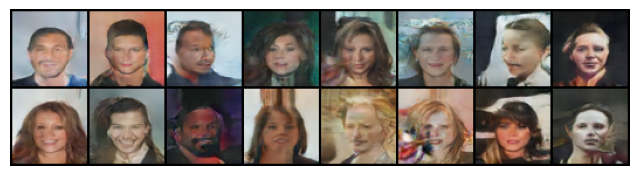

In [ ]:
with torch.no_grad():

    fake = G(fixed_noise).detach().cpu()

plt.figure(figsize=(8,8))

plt.axis("off")

plt.imshow(
    torchvision.utils.make_grid(
        fake,
        padding=2,
        normalize=True
    ).permute(1,2,0)
)

plt.show()

In [ ]:
torch.save(
    G.state_dict(),
    "generator.pth"
)

print("Generator model saved!")

Generator model saved!


In [ ]:
from google.colab import files

files.download("generator.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

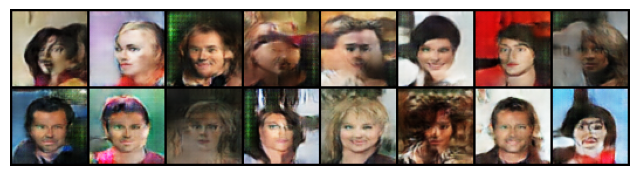

In [ ]:
noise = torch.randn(
    16,
    100,
    1,
    1,
    device=device
)

with torch.no_grad():
    fake = G(noise).detach().cpu()

plt.figure(figsize=(8,8))

plt.axis("off")

plt.imshow(
    torchvision.utils.make_grid(
        fake,
        padding=2,
        normalize=True
    ).permute(1,2,0)
)

plt.show()

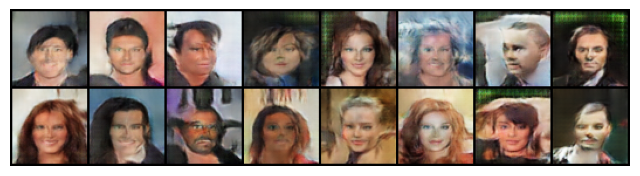

In [ ]:
if (epoch+1) % 10 == 0:

    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()

    plt.figure(figsize=(8,8))

    plt.axis("off")

    plt.imshow(
        torchvision.utils.make_grid(
            fake,
            padding=2,
            normalize=True
        ).permute(1,2,0)
    )

    plt.show()